# Labwork 3 (Simple)

In [6]:
# Sorry but I can not build a function to calculate the Logarithm from scratch
import math
from math import log as log
 
def process_dtype(raw):
    data = []
    for line in raw:
        line = line.replace("\n","").split(',')
        data.append([float(line[i]) for i in range(len(line))])
        
    return data

def load_data(path, header=True):
    with open(path, "r") as f:
        lines = f.readlines()
    data = process_dtype(lines[1:]) if header else process_dtype(lines)
    
    x, y = [], []
    for s in data:
        y.append(s[-1])
        x_i = s[:len(s)-1]
        x.append(x_i) if len(x_i)>1 else x.extend(x_i)
    
    return x, y

def sigmoid(x):
    return 1/(1+math.exp(-x))

def cal_loss(y_pred, y_true):
    loss = 0
    n = len(y_true)
    
    for y_t, y_p in zip(y_true, y_pred):
        loss += -(y_t * log(sigmoid(y_p)) + (1 - y_t) * log(1 - sigmoid(y_p)))
        
    return (1/n) * loss 
  
def grad(w, x, lb, lr):
    w2 = w[2] - lr * (1 - lb - sigmoid(-(w[0]*x[0] + w[1]*x[1] + w[2])))
    w0 = w[0] - lr * (-lb*x[0] + x[0] * (1 - sigmoid(-(w[0]*x[0] + w[1]*x[1] + w[2]))))
    w1 = w[1] - lr * (-lb*x[1] + x[1] * (1 - sigmoid(-(w[0]*x[0] + w[1]*x[1] + w[2]))))

    return [w0, w1, w2]
    
def eval(y_pred, y_true):
    count = 0
    for i in range(len(y_true)):
        if y_pred[i] == y_true[i]:
            count += 1
    return count / len(y_true)
    
def infer(w,x): # y_hat
    return w[0] * x[0] + w[1] * x[1] + w[2]

def train(x, y, lr=0.01, epochs=10, eps=0.001):
    w = [1, 1, 1]
    N = len(y)
    losses = []
    
    print("-"*60)
    print(f"Initial w: [{w[0]:.4f}, {w[1]:.4f}, {w[2]:.4f}]")
    print(f"Update w in epoch 1:")
    
    for epoch in range(epochs):
        p_pred = []
        y_pred = []
        for i in range(N):
            p = infer(w,x[i])
            pred = 1 if p >= 0.5 else 0
            p_pred.append(p)
            y_pred.append(pred)
            w = grad(w, x[i], y[i], lr)
            
            if epoch == 0:
                print(f"iter {i}: w = [{w[0]:.4f}, {w[1]:.4f}, {w[2]:.4f}]")
                if i == N-1:
                    print("-"*60)
                
        loss = cal_loss(p_pred, y)
        acc = eval(y_pred=y_pred, y_true=y)
        print(f"Epoch {epoch+1}: Loss = {loss:.8f}, training accuracy = {acc:.5f}")
        
        
        if len(losses) > 0 and abs(loss-losses[-1]) < eps:
            losses.append(loss)
            break
            
        losses.append(loss)
    print("-"*60)    
    return w, losses

In [7]:
data_path_loan = r"./loan2.csv" 
data_path_lr = r"./lr.csv"
x, y = load_data(data_path_loan, header=True)

lr = 0.01
epochs = 100
th = 1e-3

w, loss = train(x, y, lr=lr, epochs=epochs, eps=th)

------------------------------------------------------------
Initial w: [1.0000, 1.0000, 1.0000]
Update w in epoch 1:
iter 0: w = [1.0000, 1.0000, 1.0000]
iter 1: w = [1.0000, 1.0000, 1.0000]
iter 2: w = [0.9900, 0.9601, 0.9900]
iter 3: w = [0.9901, 0.9601, 0.9900]
iter 4: w = [0.9901, 0.9602, 0.9900]
iter 5: w = [0.9751, 0.9102, 0.9800]
iter 6: w = [0.9701, 0.8603, 0.9701]
iter 7: w = [0.9701, 0.8603, 0.9701]
iter 8: w = [0.9676, 0.8005, 0.9601]
iter 9: w = [0.9676, 0.8005, 0.9601]
iter 10: w = [0.9651, 0.7306, 0.9501]
iter 11: w = [0.9631, 0.6607, 0.9401]
iter 12: w = [0.9616, 0.5909, 0.9302]
iter 13: w = [0.9616, 0.5910, 0.9302]
iter 14: w = [0.9516, 0.5111, 0.9202]
iter 15: w = [0.9501, 0.4315, 0.9102]
iter 16: w = [0.9492, 0.3525, 0.9004]
iter 17: w = [0.9492, 0.3534, 0.9005]
iter 18: w = [0.9493, 0.3539, 0.9005]
------------------------------------------------------------
Epoch 1: Loss = 3.19581509, training accuracy = 0.47368
Epoch 2: Loss = 1.22244325, training accuracy = 0.526

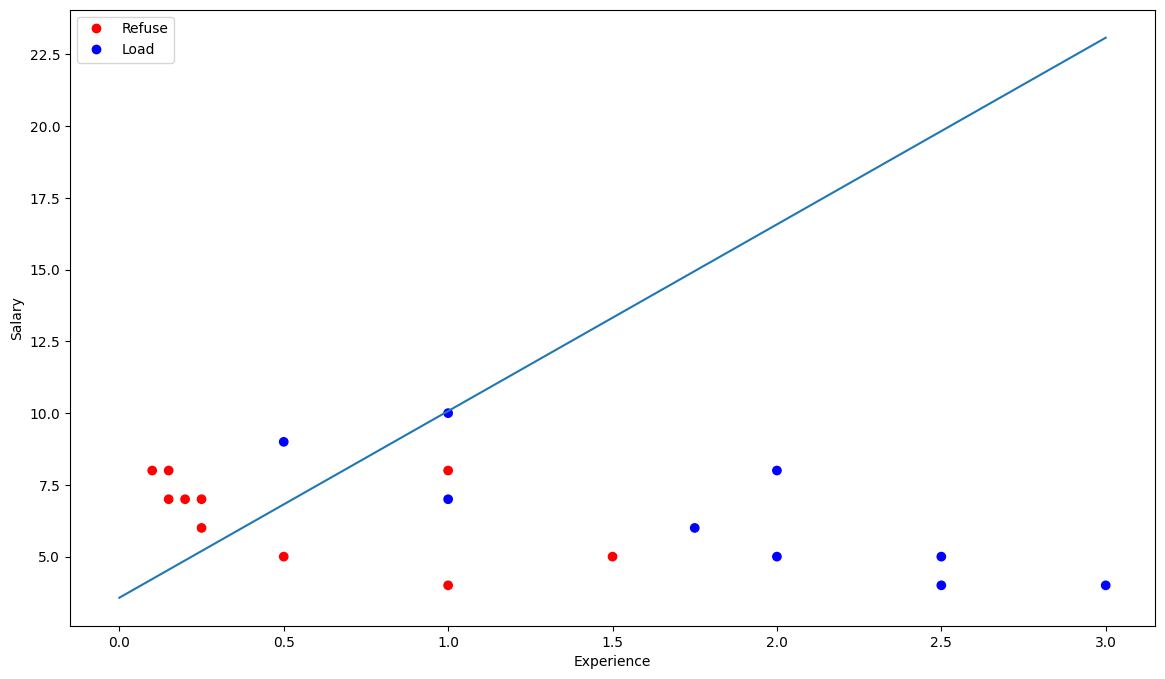

In [26]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

"""
    w0 * x0 + w1 * x1 + w2 = 0
-> x1 = - (w0 * x0 + w2) / w1
-> x1 = - (w0/w1) * x0 - w2/w1
"""
def find_line(w,x):
    return - (w[0]/w[1]) * x - w[2]/w[1]

exper = []
sala = []

x_plot = [0,3]
y_plot = [find_line(w, i_plot) for i_plot in x_plot]

for d in x:
    exper.append(d[0])
    sala.append(d[1])

cmap = {0:"red",
        1:"blue"}
l_map = {0: "Refuse",
         1: "Loan"}
custom_cmap = ListedColormap(["red", "blue"])

plt.figure(figsize=(14,8))
plt.xlabel("Experience")
plt.ylabel("Salary")

scatter = plt.scatter(exper, sala, c=y,cmap=custom_cmap)
plt.plot(x_plot,y_plot)
plt.legend(handles=scatter.legend_elements()[0], labels=["Refuse", "Load"])

plt.plot()
plt.show()